<a href="https://colab.research.google.com/github/aabyyaann/scikit-learn-Cookbook/blob/main/Chapter5_Working_with_Text_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 5 - Working with Text Data
**Book:** *scikit-learn Cookbook (O’Reilly)*  
**Name:** Naufal Alif Abyan  
**NIM:** 101032300032

Notebook ini membahas bagaimana data teks dapat diubah menjadi fitur numerik dan digunakan dalam machine learning menggunakan scikit-learn.  
Dalam machine learning, model tidak dapat langsung memahami kalimat mentah seperti manusia. Karena itu, teks perlu diubah menjadi representasi numerik terlebih dahulu, misalnya menggunakan **bag-of-words** atau **TF-IDF**.

## Tujuan Chapter
Pada chapter ini, kita akan mempelajari:
1. Konsep dasar text data dalam machine learning.
2. Cara menyiapkan dataset teks sederhana.
3. Cara menggunakan **CountVectorizer** untuk mengubah teks menjadi fitur numerik.
4. Cara menggunakan **TfidfVectorizer**.
5. Cara melatih model klasifikasi teks sederhana.
6. Cara mengevaluasi hasil model.
7. Cara melihat kata-kata yang paling berpengaruh terhadap prediksi model.

## 1. Konsep Dasar: Text as Data

Data teks adalah data tidak terstruktur yang sering ditemukan dalam:
- email
- review produk
- berita
- komentar media sosial
- dokumen

Masalah utama pada text mining adalah bahwa model machine learning membutuhkan **angka**, sedangkan teks berupa **kata dan kalimat**.

Karena itu, teks perlu diubah menjadi representasi numerik.

## Representasi teks yang umum
Beberapa pendekatan umum:
1. **Bag of Words (BoW)**  
   Menghitung kemunculan kata dalam dokumen.

2. **CountVectorizer**  
   Mengubah sekumpulan dokumen menjadi matriks frekuensi kata.

3. **TF-IDF (Term Frequency - Inverse Document Frequency)**  
   Memberi bobot lebih tinggi pada kata yang penting dalam suatu dokumen tetapi tidak terlalu sering muncul di semua dokumen.

4. **N-gram**  
   Tidak hanya satu kata (unigram), tetapi juga pasangan kata (bigram), atau tiga kata (trigram).

Pada chapter ini, kita fokus pada representasi teks klasik yang umum digunakan di scikit-learn.

In [1]:
# Import library utama
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Library Chapter 5 berhasil diimport.")

Library Chapter 5 berhasil diimport.


## 2. Menyiapkan Dataset Teks Sederhana

Agar notebook ringan dan mudah direproduksi, kita akan membuat dataset kecil sendiri.
Dataset ini berisi kalimat pendek dengan label sentimen:
- **1 = positif**
- **0 = negatif**

Contoh ini cukup untuk memahami pipeline dasar text classification.

In [2]:
texts = [
    "this movie is fantastic and inspiring",
    "i love this film so much",
    "what a wonderful and amazing story",
    "the acting was brilliant and touching",
    "this product is excellent and useful",
    "i am very happy with this purchase",
    "the service was great and satisfying",
    "absolutely loved the overall experience",

    "this movie is terrible and boring",
    "i hate this film so much",
    "what a disappointing and awful story",
    "the acting was weak and annoying",
    "this product is bad and useless",
    "i am very unhappy with this purchase",
    "the service was horrible and frustrating",
    "absolutely hated the overall experience"
]

labels = [
    1, 1, 1, 1, 1, 1, 1, 1,
    0, 0, 0, 0, 0, 0, 0, 0
]

df_text = pd.DataFrame({
    "text": texts,
    "label": labels
})

df_text

,text,label
0,this movie is fantastic and inspiring,1
1,i love this film so much,1
2,what a wonderful and amazing story,1
3,the acting was brilliant and touching,1
4,this product is excellent and useful,1
5,i am very happy with this purchase,1
6,the service was great and satisfying,1
7,absolutely loved the overall experience,1
8,this movie is terrible and boring,0
9,i hate this film so much,0


## 3. Memahami Dataset

Kita cek:
- jumlah data
- distribusi label
- beberapa contoh teks

In [3]:
print("Jumlah data:", len(df_text))
print("\nDistribusi label:")
print(df_text["label"].value_counts())

Jumlah data: 16

Distribusi label:
label
1    8
0    8
Name: count, dtype: int64


In [4]:
df_text.head(10)

,text,label
0,this movie is fantastic and inspiring,1
1,i love this film so much,1
2,what a wonderful and amazing story,1
3,the acting was brilliant and touching,1
4,this product is excellent and useful,1
5,i am very happy with this purchase,1
6,the service was great and satisfying,1
7,absolutely loved the overall experience,1
8,this movie is terrible and boring,0
9,i hate this film so much,0


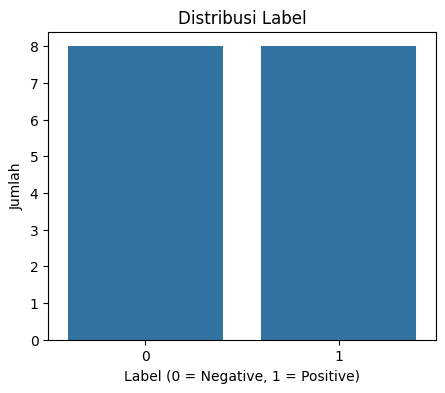

In [5]:
plt.figure(figsize=(5, 4))
sns.countplot(x="label", data=df_text)
plt.title("Distribusi Label")
plt.xlabel("Label (0 = Negative, 1 = Positive)")
plt.ylabel("Jumlah")
plt.show()

## 4. Train-Test Split

Kita membagi data menjadi:
- **training set** untuk melatih model
- **test set** untuk mengevaluasi model

Karena dataset kecil, kita tetap gunakan `stratify` agar distribusi label tetap seimbang.

In [6]:
X = df_text["text"]
y = df_text["label"]

text_train, text_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Jumlah data train:", len(text_train))
print("Jumlah data test :", len(text_test))

Jumlah data train: 12
Jumlah data test : 4


## 5. CountVectorizer

`CountVectorizer` mengubah kumpulan dokumen menjadi matriks frekuensi kata.

### Cara kerjanya:
1. memecah teks menjadi token/kata,
2. membangun vocabulary dari data training,
3. menghitung berapa kali tiap kata muncul pada setiap dokumen.

Output akhirnya berupa matriks:
- baris = dokumen
- kolom = kata
- isi = frekuensi kata

In [7]:
vect = CountVectorizer()
vect.fit(text_train)

X_train_count = vect.transform(text_train)
X_test_count = vect.transform(text_test)

print("Shape data train hasil CountVectorizer:", X_train_count.shape)
print("Shape data test hasil CountVectorizer :", X_test_count.shape)

Shape data train hasil CountVectorizer: (12, 39)
Shape data test hasil CountVectorizer : (4, 39)


In [8]:
feature_names = vect.get_feature_names_out()

print("Jumlah vocabulary:", len(feature_names))
print("20 kata pertama dalam vocabulary:")
print(feature_names[:20])

Jumlah vocabulary: 39
20 kata pertama dalam vocabulary:
['absolutely' 'acting' 'am' 'amazing' 'and' 'awful' 'bad' 'boring'
 'brilliant' 'disappointing' 'excellent' 'experience' 'fantastic' 'film'
 'happy' 'hate' 'hated' 'inspiring' 'is' 'loved']


## 6. Melihat Matriks Fitur CountVectorizer

Matriks hasil vectorizer biasanya berbentuk **sparse matrix** karena tidak semua kata muncul di semua dokumen.

Agar mudah dibaca, kita ubah sebagian kecil ke DataFrame.

In [9]:
count_df = pd.DataFrame(
    X_train_count.toarray(),
    columns=feature_names,
    index=text_train.index
)

count_df.head()

,absolutely,acting,am,amazing,and,awful,bad,boring,brilliant,disappointing,...,this,touching,unhappy,useful,useless,very,was,what,with,wonderful
5,0,0,1,0,0,0,0,0,0,0,...,1,0,0,0,0,1,0,0,1,0
4,0,0,0,0,1,0,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
0,0,0,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
3,0,1,0,0,1,0,0,0,1,0,...,0,1,0,0,0,0,1,0,0,0


## 7. Melatih Model Klasifikasi Teks dengan CountVectorizer

Setelah teks berubah menjadi fitur numerik, kita bisa melatih model klasifikasi.  
Untuk chapter ini kita gunakan **Logistic Regression** karena:
- umum digunakan pada text classification,
- cukup cepat,
- mudah dijelaskan.

In [10]:
model_count = LogisticRegression(max_iter=1000)
model_count.fit(X_train_count, y_train)

print("Model Logistic Regression + CountVectorizer berhasil dilatih.")

Model Logistic Regression + CountVectorizer berhasil dilatih.


## 8. Evaluasi Model CountVectorizer
Kita evaluasi model menggunakan:
- accuracy
- classification report
- confusion matrix

In [11]:
y_pred_count = model_count.predict(X_test_count)

acc_count = accuracy_score(y_test, y_pred_count)
print("Accuracy (CountVectorizer):", round(acc_count, 4))

Accuracy (CountVectorizer): 0.25


In [12]:
print("Classification Report - CountVectorizer")
print(classification_report(y_test, y_pred_count))

Classification Report - CountVectorizer
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.33      0.50      0.40         2

    accuracy                           0.25         4
   macro avg       0.17      0.25      0.20         4
weighted avg       0.17      0.25      0.20         4



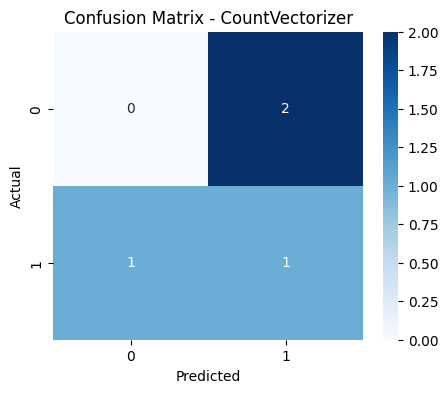

In [13]:
cm_count = confusion_matrix(y_test, y_pred_count)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_count, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - CountVectorizer")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 9. TF-IDF Vectorization

Selain menghitung frekuensi kata, kita juga bisa menggunakan **TF-IDF**.

### Intuisi TF-IDF
- kata yang sering muncul dalam satu dokumen → penting
- tetapi jika kata itu muncul di hampir semua dokumen → bobotnya dikurangi

Dengan begitu, TF-IDF membantu menyoroti kata yang lebih informatif.

In [14]:
tfidf = TfidfVectorizer()
tfidf.fit(text_train)

X_train_tfidf = tfidf.transform(text_train)
X_test_tfidf = tfidf.transform(text_test)

print("Shape train TF-IDF:", X_train_tfidf.shape)
print("Shape test TF-IDF :", X_test_tfidf.shape)

Shape train TF-IDF: (12, 39)
Shape test TF-IDF : (4, 39)


In [15]:
tfidf_features = tfidf.get_feature_names_out()

print("Jumlah vocabulary TF-IDF:", len(tfidf_features))
print("20 kata pertama TF-IDF vocabulary:")
print(tfidf_features[:20])

Jumlah vocabulary TF-IDF: 39
20 kata pertama TF-IDF vocabulary:
['absolutely' 'acting' 'am' 'amazing' 'and' 'awful' 'bad' 'boring'
 'brilliant' 'disappointing' 'excellent' 'experience' 'fantastic' 'film'
 'happy' 'hate' 'hated' 'inspiring' 'is' 'loved']


## 10. Melihat Nilai TF-IDF dalam Bentuk Tabel
Agar lebih mudah dipahami, kita ubah matriks TF-IDF menjadi DataFrame untuk beberapa dokumen training.

In [16]:
tfidf_df = pd.DataFrame(
    X_train_tfidf.toarray(),
    columns=tfidf_features,
    index=text_train.index
)

tfidf_df.head()

,absolutely,acting,am,amazing,and,awful,bad,boring,brilliant,disappointing,...,this,touching,unhappy,useful,useless,very,was,what,with,wonderful
5,0.0,0.0000,0.418172,0.0,0.000000,0.0,0.0,0.0,0.0000,0.0,...,0.251871,0.0000,0.0,0.000000,0.0,0.418172,0.0000,0.0,0.418172,0.0
4,0.0,0.0000,0.000000,0.0,0.267606,0.0,0.0,0.0,0.0000,0.0,...,0.267606,0.0000,0.0,0.517339,0.0,0.000000,0.0000,0.0,0.000000,0.0
9,0.0,0.0000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0000,0.0,...,0.250397,0.0000,0.0,0.000000,0.0,0.000000,0.0000,0.0,0.000000,0.0
0,0.0,0.0000,0.000000,0.0,0.267606,0.0,0.0,0.0,0.0000,0.0,...,0.267606,0.0000,0.0,0.000000,0.0,0.000000,0.0000,0.0,0.000000,0.0
3,0.0,0.4544,0.000000,0.0,0.235049,0.0,0.0,0.0,0.4544,0.0,...,0.000000,0.4544,0.0,0.000000,0.0,0.000000,0.4544,0.0,0.000000,0.0


## 11. Melatih Model Klasifikasi Teks dengan TF-IDF

Sekarang kita latih model Logistic Regression kedua, tetapi menggunakan fitur TF-IDF.

In [17]:
model_tfidf = LogisticRegression(max_iter=1000)
model_tfidf.fit(X_train_tfidf, y_train)

print("Model Logistic Regression + TF-IDF berhasil dilatih.")

Model Logistic Regression + TF-IDF berhasil dilatih.


## 12. Evaluasi Model TF-IDF
Kita hitung akurasi, classification report, dan confusion matrix.

In [18]:
y_pred_tfidf = model_tfidf.predict(X_test_tfidf)

acc_tfidf = accuracy_score(y_test, y_pred_tfidf)
print("Accuracy (TF-IDF):", round(acc_tfidf, 4))

Accuracy (TF-IDF): 0.25


In [19]:
print("Classification Report - TF-IDF")
print(classification_report(y_test, y_pred_tfidf))

Classification Report - TF-IDF
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.33      0.50      0.40         2

    accuracy                           0.25         4
   macro avg       0.17      0.25      0.20         4
weighted avg       0.17      0.25      0.20         4



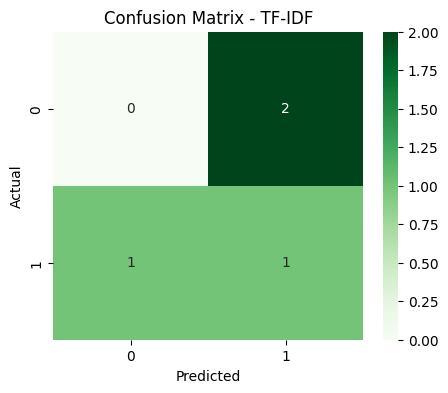

In [20]:
cm_tfidf = confusion_matrix(y_test, y_pred_tfidf)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_tfidf, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - TF-IDF")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 13. Membandingkan CountVectorizer vs TF-IDF

Sekarang kita bandingkan performa dua pendekatan:
1. Logistic Regression + CountVectorizer
2. Logistic Regression + TF-IDF

In [21]:
comparison = pd.DataFrame({
    "Method": [
        "Logistic Regression + CountVectorizer",
        "Logistic Regression + TF-IDF"
    ],
    "Accuracy": [
        acc_count,
        acc_tfidf
    ]
})

comparison

,Method,Accuracy
0,Logistic Regression + CountVectorizer,0.25
1,Logistic Regression + TF-IDF,0.25


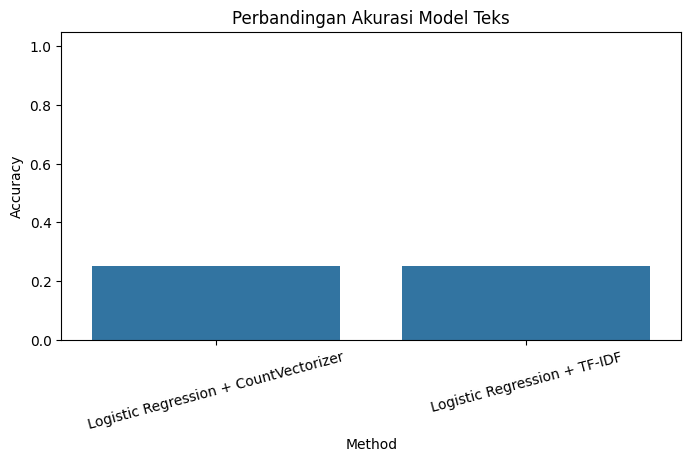

In [22]:
plt.figure(figsize=(8, 4))
sns.barplot(data=comparison, x="Method", y="Accuracy")
plt.title("Perbandingan Akurasi Model Teks")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.show()

## 14. Melihat Kata Paling Berpengaruh pada Model

Salah satu kelebihan Logistic Regression adalah kita bisa melihat koefisien model.

- Koefisien positif besar → kata mendorong prediksi ke kelas positif
- Koefisien negatif besar → kata mendorong prediksi ke kelas negatif

Di sini kita gunakan model TF-IDF untuk interpretasi.

In [23]:
coef = model_tfidf.coef_[0]
feature_names = tfidf.get_feature_names_out()

coef_df = pd.DataFrame({
    "word": feature_names,
    "coefficient": coef
})

coef_df = coef_df.sort_values("coefficient")
coef_df.head()

,word,coefficient
16,hated,-0.245015
5,awful,-0.229777
9,disappointing,-0.229777
7,boring,-0.227509
27,terrible,-0.227509


In [24]:
top_negative = coef_df.head(10)
top_positive = coef_df.tail(10)

print("Top kata negatif:")
display(top_negative)

print("\nTop kata positif:")
display(top_positive)

Top kata negatif:


,word,coefficient
16,hated,-0.245015
5,awful,-0.229777
9,disappointing,-0.229777
7,boring,-0.227509
27,terrible,-0.227509
6,bad,-0.227509
33,useless,-0.227509
31,unhappy,-0.227044
21,much,-0.193444
15,hate,-0.193444



Top kata positif:


,word,coefficient
30,touching,0.183205
8,brilliant,0.183205
3,amazing,0.226582
38,wonderful,0.226582
10,excellent,0.229145
12,fantastic,0.229145
17,inspiring,0.229145
32,useful,0.229145
14,happy,0.232608
19,loved,0.236993


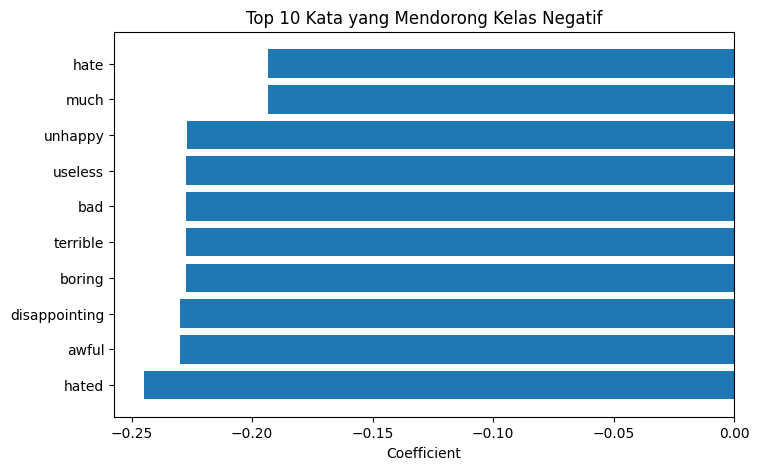

In [25]:
plt.figure(figsize=(8, 5))
plt.barh(top_negative["word"], top_negative["coefficient"])
plt.title("Top 10 Kata yang Mendorong Kelas Negatif")
plt.xlabel("Coefficient")
plt.show()

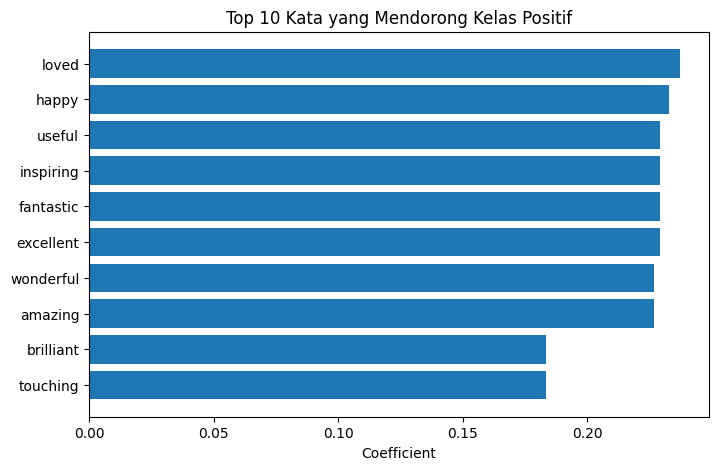

In [26]:
plt.figure(figsize=(8, 5))
plt.barh(top_positive["word"], top_positive["coefficient"])
plt.title("Top 10 Kata yang Mendorong Kelas Positif")
plt.xlabel("Coefficient")
plt.show()

## 15. Prediksi Kalimat Baru

Sekarang kita coba gunakan model untuk memprediksi sentimen dari beberapa kalimat baru.

In [27]:
new_texts = [
    "this movie is amazing and wonderful",
    "the service was terrible and disappointing",
    "i am happy with this excellent product",
    "this experience was awful and boring"
]

new_tfidf = tfidf.transform(new_texts)
new_preds = model_tfidf.predict(new_tfidf)

result_df = pd.DataFrame({
    "text": new_texts,
    "predicted_label": new_preds
})

result_df["predicted_sentiment"] = result_df["predicted_label"].map({
    1: "Positive",
    0: "Negative"
})

result_df

,text,predicted_label,predicted_sentiment
0,this movie is amazing and wonderful,1,Positive
1,the service was terrible and disappointing,0,Negative
2,i am happy with this excellent product,1,Positive
3,this experience was awful and boring,0,Negative


## 16. Interpretasi Hasil Prediksi Baru

Dari hasil prediksi, kita bisa melihat bahwa model belajar dari kata-kata bernuansa:
- positif: *amazing, wonderful, excellent, happy*
- negatif: *terrible, disappointing, awful, boring*

Meskipun dataset yang digunakan kecil, alur ini sudah menunjukkan bagaimana text classification bekerja:
1. teks mentah dikumpulkan,
2. teks diubah menjadi fitur numerik,
3. model dilatih,
4. model dipakai untuk memprediksi teks baru.

## 17. Ringkasan Chapter 5

Pada chapter ini kita mempelajari alur dasar pengolahan data teks untuk machine learning.

### Hal-hal penting yang dipelajari:
1. **Teks harus diubah menjadi angka** agar bisa digunakan oleh model machine learning.
2. **CountVectorizer** merepresentasikan dokumen sebagai frekuensi kata.
3. **TF-IDF** memberi bobot pada kata berdasarkan pentingnya dalam dokumen.
4. Setelah menjadi fitur numerik, teks bisa diproses seperti data tabular biasa.
5. **Logistic Regression** adalah model sederhana yang efektif untuk klasifikasi teks.
6. Koefisien model dapat digunakan untuk melihat kata yang paling memengaruhi prediksi.

Chapter ini penting karena text mining merupakan salah satu aplikasi machine learning yang sangat umum di dunia nyata.

## 18. Kesimpulan Chapter 5

Kesimpulan utama dari chapter ini adalah:
- Data teks tidak bisa langsung diproses model, sehingga perlu vectorization.
- **CountVectorizer** dan **TF-IDF** adalah dua teknik dasar yang sangat penting dalam NLP klasik berbasis scikit-learn.
- Setelah teks diubah menjadi matriks fitur, kita dapat menggunakan model klasifikasi seperti Logistic Regression.
- Evaluasi model tetap penting, bahkan untuk dataset sederhana.
- Interpretasi koefisien model membantu memahami hubungan antara kata dan prediksi.

Dengan memahami chapter ini, kita memiliki dasar yang kuat untuk memproses data teks sebelum masuk ke topik NLP yang lebih kompleks.